# Machine Learning with PyTorch and Scikit-Learn  
# -- Code Examples

## Package version checks

Add folder to path in order to load from the check_packages.py script:

In [254]:
import sys
sys.path.insert(0, '..')

Check recommended package versions:

In [255]:
# from python_environment_check import check_packages


# d = {
#     'torch': '1.8.0',
#     'networkx': '2.6.2',
#     'numpy': '1.21.2',
# }

# check_packages(d)

In [256]:
from IPython.display import Image
%matplotlib inline

## Introduction to graph data

In [257]:
import networkx as nx
import numpy as np
dir(nx)
print(nx.__version__)

3.6.1


In [258]:
G0,G1,G2,G3,G4,G5 = nx.Graph(), nx.Graph(), nx.Graph(), nx.Graph(), nx.Graph(), nx.Graph()

#Hex codes for colors if we draw graph
carbon, oxygen, nitrogen = "#1f77b4", "#ff7f0e","#2ca02c"

G0.add_nodes_from([(1, {"color": carbon}),
                  (2, {"color": oxygen}),
                  (3, {"color": carbon}),
                  (4, {"color": nitrogen})])

G0.add_edges_from([(1, 2),(2, 3),(1, 3),(3, 4)])

G1.add_nodes_from([(1, {"color": carbon}),
                  (2, {"color": nitrogen}),
                  (3, {"color": carbon}),
                  (4, {"color": nitrogen})])
G1.add_edges_from([(1, 2),(2, 3),(1, 3),(2, 4)])

G2.add_nodes_from([(1, {"color": carbon}),
                  (2, {"color": oxygen}),
                  (3, {"color": carbon}),
                  (4, {"color": nitrogen}),
                  (5, {"color": carbon})])
G2.add_edges_from([(2, 3),(1, 3),(3, 4),(4, 5),(4,1)])

G3.add_nodes_from([(1, {"color": carbon}),
                  (2, {"color": oxygen}),
                  (3, {"color": carbon}),
                  (4, {"color": nitrogen}),
                  (5, {"color": carbon})])
G3.add_edges_from([(1, 5),(2, 3),(1, 3),(4, 5),(2,5),(1,4)])

G4.add_nodes_from([(1, {"color": carbon}),
                  (2, {"color": oxygen}),
                  (3, {"color": carbon}),
                  (4, {"color": oxygen}),
                  (5, {"color": oxygen}),
                  (6, {"color": oxygen})])
G4.add_edges_from([(1, 2),(2, 3), (3,1),(4, 5),(5, 6),(4,1),(3,5)])

G5.add_nodes_from([(1, {"color": carbon}),
                  (2, {"color": oxygen}),
                  (3, {"color": carbon}),
                  (4, {"color": nitrogen}),
                  (5, {"color": nitrogen}),
                  (6, {"color": oxygen})])
G5.add_edges_from([(1, 2),(2, 3),(1, 3),(5, 6),(1, 6), (4,6)])

print("Adjacency matrix of G0: ")
A = np.asarray(nx.adjacency_matrix(G0).todense())
print(A)
print("Adjacency matrix of G1: ")
A1 = np.asarray(nx.adjacency_matrix(G1).todense())
print(A1)
print("Adjacency matrix of G2: ")
A2 = np.asarray(nx.adjacency_matrix(G2).todense())
print(A2)
print("Adjacency matrix of G3: ")
A3 = np.asarray(nx.adjacency_matrix(G3).todense())
print(A3)
print("Adjacency matrix of G4: ")
A4 = np.asarray(nx.adjacency_matrix(G4).todense())
print(A4)
print("Adjacency matrix of G5: ")
A5 = np.asarray(nx.adjacency_matrix(G5).todense())
print(A5)


Adjacency matrix of G0: 
[[0 1 1 0]
 [1 0 1 0]
 [1 1 0 1]
 [0 0 1 0]]
Adjacency matrix of G1: 
[[0 1 1 0]
 [1 0 1 1]
 [1 1 0 0]
 [0 1 0 0]]
Adjacency matrix of G2: 
[[0 0 1 1 0]
 [0 0 1 0 0]
 [1 1 0 1 0]
 [1 0 1 0 1]
 [0 0 0 1 0]]
Adjacency matrix of G3: 
[[0 0 1 1 1]
 [0 0 1 0 1]
 [1 1 0 0 0]
 [1 0 0 0 1]
 [1 1 0 1 0]]
Adjacency matrix of G4: 
[[0 1 1 1 0 0]
 [1 0 1 0 0 0]
 [1 1 0 0 1 0]
 [1 0 0 0 1 0]
 [0 0 1 1 0 1]
 [0 0 0 0 1 0]]
Adjacency matrix of G5: 
[[0 1 1 0 0 1]
 [1 0 1 0 0 0]
 [1 1 0 0 0 0]
 [0 0 0 0 0 1]
 [0 0 0 0 0 1]
 [1 0 0 1 1 0]]


In [259]:
mapping_dict = {carbon: 0, oxygen: 1, nitrogen: 2}


[0 1 0 2]
One-hot encoding of node colors in G0: 
[[1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]


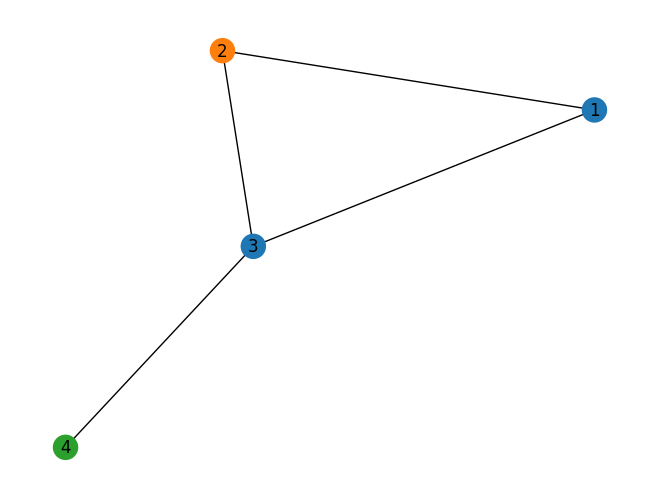

In [260]:
def build_graph_color_label_representation(G,mapping_dict):
    one_hot_idxs = np.array([mapping_dict[v] for v in 
                             nx.get_node_attributes(G, 'color').values()])
    color_map = nx.get_node_attributes(G, 'color').values()
    nx.draw(G, with_labels=True, node_color=color_map)

    print(one_hot_idxs);
    one_hot_encoding = np.zeros((one_hot_idxs.size,len(mapping_dict)))
    one_hot_encoding[np.arange(one_hot_idxs.size),one_hot_idxs] = 1
    return one_hot_encoding

X0 = build_graph_color_label_representation(G0, mapping_dict)
print("One-hot encoding of node colors in G0: ")
print(X0)



[0 2 0 2]
One-hot encoding of node colors in G1: 
[[1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]


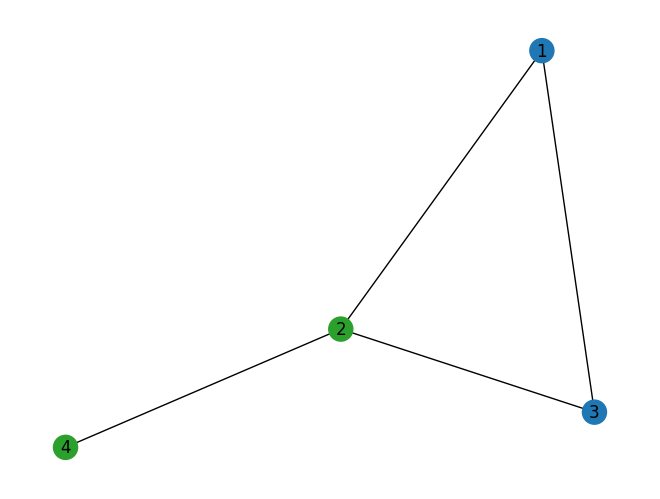

In [261]:
X1 = build_graph_color_label_representation(G1, mapping_dict)
print("One-hot encoding of node colors in G1: ")
print(X1)


[0 1 0 2 0]
One-hot encoding of node colors in G2: 
[[1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]


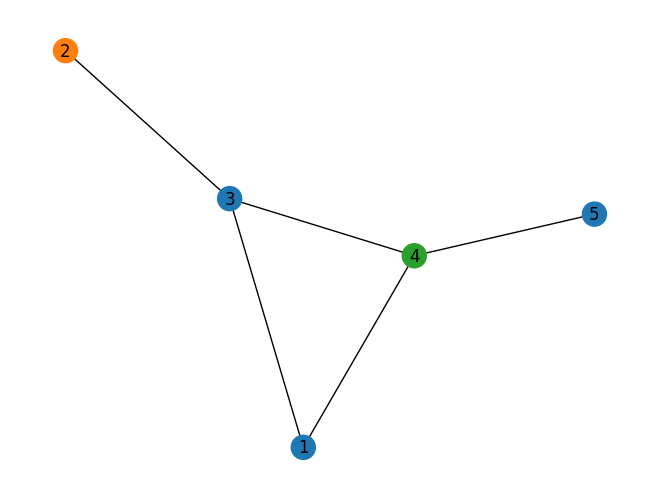

In [262]:

X2 = build_graph_color_label_representation(G2, mapping_dict)
print("One-hot encoding of node colors in G2: ")
print(X2)


[0 1 0 2 0]
One-hot encoding of node colors in G3: 
[[1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]


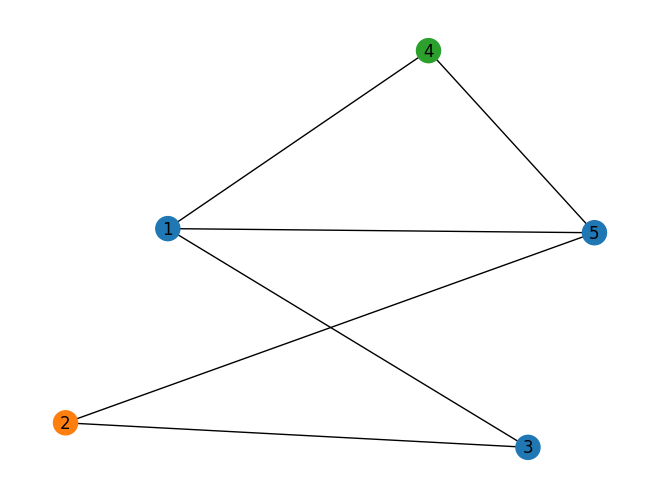

In [263]:

X3 = build_graph_color_label_representation(G3, mapping_dict)
print("One-hot encoding of node colors in G3: ")
print(X3)



[0 1 0 1 1 1]
One-hot encoding of node colors in G4: 
[[1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]]


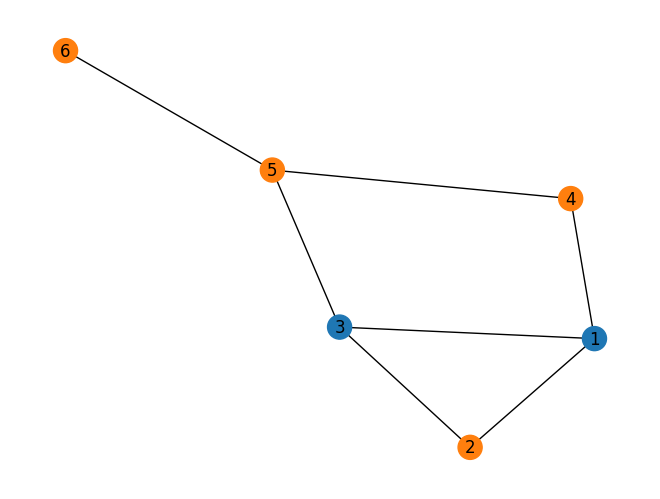

In [264]:
X4 = build_graph_color_label_representation(G4, mapping_dict)
print("One-hot encoding of node colors in G4: ")
print(X4)


[0 1 0 2 2 1]
One-hot encoding of node colors in G5: 
[[1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]]


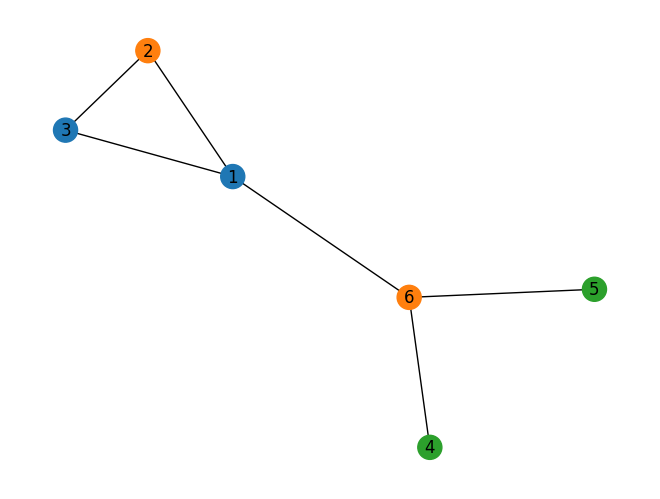

In [265]:

X5 = build_graph_color_label_representation(G5, mapping_dict)
print("One-hot encoding of node colors in G5: ")
print(X5)

In [266]:

def print_adjacency_and_feature_matrices(G):
    color_map = nx.get_node_attributes(G, 'color').values()

    A = np.asarray(nx.adjacency_matrix(G).todense())
    print("Adjacency matrix: ")
    print(A)
    return A

A0 = print_adjacency_and_feature_matrices(G0)
A1 = print_adjacency_and_feature_matrices(G1)
A2 = print_adjacency_and_feature_matrices(G2)
A3 = print_adjacency_and_feature_matrices(G3)
A4 = print_adjacency_and_feature_matrices(G4)
A5 = print_adjacency_and_feature_matrices(G5)


Adjacency matrix: 
[[0 1 1 0]
 [1 0 1 0]
 [1 1 0 1]
 [0 0 1 0]]
Adjacency matrix: 
[[0 1 1 0]
 [1 0 1 1]
 [1 1 0 0]
 [0 1 0 0]]
Adjacency matrix: 
[[0 0 1 1 0]
 [0 0 1 0 0]
 [1 1 0 1 0]
 [1 0 1 0 1]
 [0 0 0 1 0]]
Adjacency matrix: 
[[0 0 1 1 1]
 [0 0 1 0 1]
 [1 1 0 0 0]
 [1 0 0 0 1]
 [1 1 0 1 0]]
Adjacency matrix: 
[[0 1 1 1 0 0]
 [1 0 1 0 0 0]
 [1 1 0 0 1 0]
 [1 0 0 0 1 0]
 [0 0 1 1 0 1]
 [0 0 0 0 1 0]]
Adjacency matrix: 
[[0 1 1 0 0 1]
 [1 0 1 0 0 0]
 [1 1 0 0 0 0]
 [0 0 0 0 0 1]
 [0 0 0 0 0 1]
 [1 0 0 1 1 0]]


In [267]:
color_map = nx.get_node_attributes(G0, 'color').values()
print("node attrbutes: ",nx.get_node_attributes(G0, 'color'))
print("color_map: ", color_map)

node attrbutes:  {1: '#1f77b4', 2: '#ff7f0e', 3: '#1f77b4', 4: '#2ca02c'}
color_map:  dict_values(['#1f77b4', '#ff7f0e', '#1f77b4', '#2ca02c'])


node attrbutes:  {1: '#1f77b4', 2: '#ff7f0e', 3: '#1f77b4', 4: '#2ca02c'}
color_map:  dict_values(['#1f77b4', '#ff7f0e', '#1f77b4', '#2ca02c'])


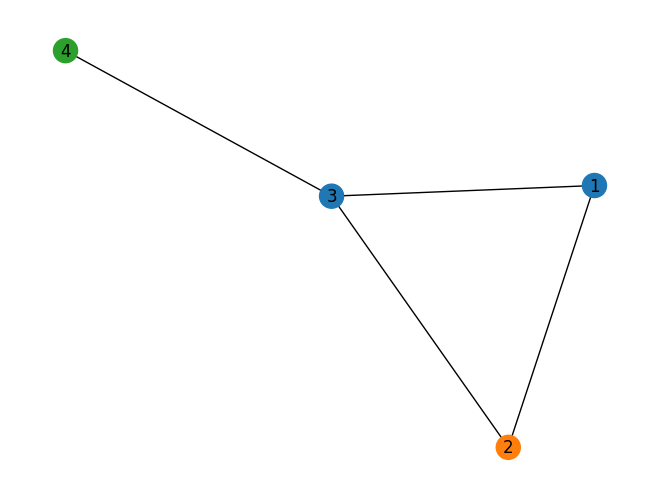

In [268]:
color_map = nx.get_node_attributes(G0, 'color').values()
print("node attrbutes: ",nx.get_node_attributes(G0, 'color'))
print("color_map: ", color_map)
nx.draw(G0, with_labels=True, node_color=color_map)

In [269]:
f_in, f_out = X0.shape[1], 6
W_1 = np.random.rand(f_in, f_out) 
W_2 = np.random.rand(f_in, f_out) 
h = np.dot(X0,W_1) + np.dot(np.dot(A, X0), W_2)

## Implementing a GNN in PyTorch from scratch

### Defining the NodeNetwork model

In [270]:
import networkx as nx
import torch
from torch.nn.parameter import Parameter
from torch.utils.data import DataLoader, Dataset
import numpy as np
import torch.nn.functional as F

In [271]:
class NodeNetwork(torch.nn.Module):

    def __init__(self, input_features):
        super().__init__()
        
        self.conv_1 = BasicGraphConvolutionLayer(input_features, 32)
        self.conv_2 = BasicGraphConvolutionLayer(32, 32)
        self.fc_1 = torch.nn.Linear(32, 16)
        self.out_layer = torch.nn.Linear(16, 2)
    
    def forward(self, X, A,batch_mat):
        x = self.conv_1(X, A).clamp(0)
        x = self.conv_2(x, A).clamp(0)
        output = global_sum_pool(x, batch_mat)
        output = self.fc_1(output)
        output = self.out_layer(output)
        return F.softmax(output, dim=1)

### Coding the NodeNetwork’s graph convolution layer

In [272]:
class BasicGraphConvolutionLayer(torch.nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        
        self.W2 = Parameter(torch.rand(
             (in_channels, out_channels), dtype=torch.float32))
        self.W1 = Parameter(torch.rand(
             (in_channels, out_channels), dtype=torch.float32))
         
        self.bias = Parameter(torch.zeros(
                 out_channels, dtype=torch.float32))
    
    def forward(self, X, A):
        potential_msgs = torch.mm(X, self.W2)
        propagated_msgs = torch.mm(A, potential_msgs)
        root_update = torch.mm(X, self.W1)
        output = propagated_msgs + root_update + self.bias
        return output

In [273]:
print('X.shape:', X0.shape)
print('A.shape:', A.shape)

X.shape: (4, 3)
A.shape: (4, 4)


### Adding a global pooling layer to deal with varying graph sizes

In [274]:
def global_sum_pool(X, batch_mat):
    if batch_mat is None or batch_mat.dim() == 1:
        return torch.sum(X, dim=0).unsqueeze(0)
    else:
        return torch.mm(batch_mat, X)

In [275]:
def get_batch_tensor(graph_sizes):
    starts = [sum(graph_sizes[:idx]) for idx in range(len(graph_sizes))]
    stops = [starts[idx]+graph_sizes[idx] for idx in range(len(graph_sizes))]
    tot_len = sum(graph_sizes)
    batch_size = len(graph_sizes)
    batch_mat = torch.zeros([batch_size, tot_len]).float()
    for idx, starts_and_stops in enumerate(zip(starts, stops)):
        start = starts_and_stops[0]
        stop = starts_and_stops[1]
        batch_mat[idx, start:stop] = 1
    return batch_mat

In [276]:
carbon, oxygen, nitrogen = "#1f77b4", "#ff7f0e","#2ca02c"
mapping_dict = {carbon: 0, oxygen: 1, nitrogen: 2}
def build_graph_color_label_representation(G, mapping_dict):
    one_hot_idxs = np.array([mapping_dict[v] for v in
    nx.get_node_attributes(G, 'color').values()])
    nx.draw(G, with_labels=True, node_color=nx.get_node_attributes(G, 'color').values())
    one_hot_encoding = np.zeros(
    (one_hot_idxs.size, len(mapping_dict)))
    one_hot_encoding[
    np.arange(one_hot_idxs.size), one_hot_idxs] = 1
    return one_hot_encoding


In [277]:
def collate_graphs(batch):
    adj_mats = [graph['A'] for graph in batch]
    sizes = [A.size(0) for A in adj_mats]
    tot_size = sum(sizes)
    # create batch matrix
    batch_mat = get_batch_tensor(sizes)
    # combine feature matrices
    feat_mats = torch.cat([graph['X'] for graph in batch],dim=0)
    # combine labels
    labels = torch.cat([graph['y'] for graph in batch], dim=0)
    # combine adjacency matrices
    batch_adj = torch.zeros([tot_size, tot_size], dtype=torch.float32)
    accum = 0
    for adj in adj_mats:
        g_size = adj.shape[0]
        batch_adj[accum:accum+g_size, accum:accum+g_size] = adj
        accum = accum + g_size
    repr_and_label = {
            'A': batch_adj, 
            'X': feat_mats,
            'y': labels,
            'batch' : batch_mat}

    return repr_and_label

### Preparing the DataLoader

[{'A': tensor([[0., 1., 1., 0.],
        [1., 0., 1., 0.],
        [1., 1., 0., 1.],
        [0., 0., 1., 0.]]), 'X': tensor([[1., 0., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 1.]]), 'y': tensor([[1., 0.]]), 'batch': None}, {'A': tensor([[0., 1., 0., 0.],
        [1., 0., 1., 0.],
        [0., 1., 0., 1.],
        [0., 0., 1., 0.]]), 'X': tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]), 'y': tensor([[1., 0.]]), 'batch': None}, {'A': tensor([[0., 1., 1., 0., 0.],
        [1., 0., 1., 0., 0.],
        [1., 1., 0., 1., 0.],
        [0., 0., 1., 0., 1.],
        [0., 0., 0., 1., 0.]]), 'X': tensor([[1., 0., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [1., 0., 0.]]), 'y': tensor([[1., 0.]]), 'batch': None}, {'A': tensor([[0., 1., 0., 0., 0.],
        [1., 0., 1., 0., 0.],
        [0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 1., 0.]]), 'X': tensor([[1., 0., 0.],
  

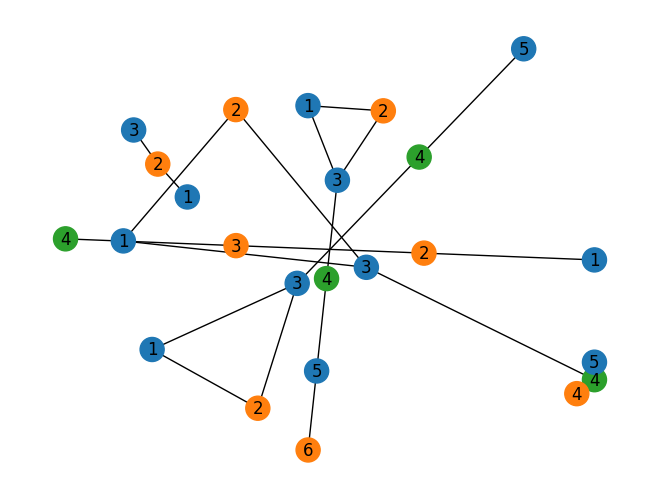

In [278]:
def get_graph_dict(G, mapping_dict):
    # build dictionary representation of graph G
    A = torch.from_numpy(np.asarray(nx.adjacency_matrix(G).todense())).float()
    # build_graph_color_label_representation() was introduced with the first example graph
    X = torch.from_numpy(build_graph_color_label_representation(G,mapping_dict)).float()
    # kludge since there is not specific task for this example
    y = torch.tensor([[1, 0]]).float()
    return {'A': A, 'X': X, 'y': y, 'batch': None}
    
# building 4 graphs to treat as a dataset

G0,G1,G2,G3,G4,G5 = nx.Graph(), nx.Graph(), nx.Graph(), nx.Graph(), nx.Graph(), nx.Graph()

#Hex codes for colors if we draw graph
carbon, oxygen, nitrogen = "#1f77b4", "#ff7f0e","#2ca02c"

G0.add_nodes_from([(1, {"color": carbon}),
                  (2, {"color": oxygen}),
                  (3, {"color": carbon}),
                  (4, {"color": nitrogen})])

G0.add_edges_from([(1, 2),(2, 3),(1, 3),(3, 4)])

G1.add_nodes_from([(1, {"color": carbon}),
                  (2, {"color": oxygen}),
                  (3, {"color": oxygen}),
                  (4, {"color": nitrogen})])
G1.add_edges_from([(1, 2),(2, 3),(3, 4)])

G2.add_nodes_from([(1, {"color": carbon}),
                  (2, {"color": oxygen}),
                  (3, {"color": carbon}),
                  (4, {"color": nitrogen}),
                  (5, {"color": carbon})])
G2.add_edges_from([(1, 2),(2, 3),(1, 3),(3, 4),(4, 5)])

G3.add_nodes_from([(1, {"color": carbon}),
                  (2, {"color": oxygen}),
                  (3, {"color": carbon}),
                  (4, {"color": oxygen}),
                  (5, {"color": carbon})])
G3.add_edges_from([(1, 2),(2, 3),(4, 5)])

G4.add_nodes_from([(1, {"color": carbon}),
                  (2, {"color": oxygen}),
                  (3, {"color": carbon}),
                  (4, {"color": nitrogen}),
                  (5, {"color": carbon}),
                  (6, {"color": oxygen})])
G4.add_edges_from([(1, 2),(2, 3),(1, 3),(3, 4),(4, 5),(5, 6)])

graph_list = [get_graph_dict(graph,mapping_dict) for graph in [G0, G1, G2, G3, G4]]
print(graph_list)

In [279]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader


class ExampleDataset(Dataset):
    
    # Simple PyTorch dataset that will use our list of graphs
    def __init__(self, graph_list):
        self.graphs = graph_list
        
    def __len__(self):
        return len(self.graphs)
    
    def __getitem__(self,idx):
        mol_rep = self.graphs[idx]
        return mol_rep

In [280]:
dset = ExampleDataset(graph_list)
# Note how we use our custom collate function
loader = DataLoader(dset, batch_size=2, shuffle=False, collate_fn=collate_graphs)

### Using the NodeNetwork to make predictions

In [281]:
torch.manual_seed(123)
node_features = 3
net = NodeNetwork(node_features)

In [282]:
batch_results = []

for b in loader:
    batch_results.append(net(b['X'], b['A'], b['batch']).detach())

G1_rep = dset[1]
G1_single = net(G1_rep['X'], G1_rep['A'], G1_rep['batch']).detach()

G1_batch = batch_results[0][1]
torch.all(torch.isclose(G1_single, G1_batch))

G0_rep = dset[0]
G0_single = net(G0_rep['X'], G0_rep['A'], G0_rep['batch']).detach()

G0_batch = batch_results[0][0]
torch.all(torch.isclose(G0_single, G0_batch))

tensor(True)